In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Imports OK")

Imports OK


In [2]:
malmem = pd.read_parquet(r"C:\PFA_Malware\data\raw\Obfuscated-MalMem2022.parquet")

def simplify_category(cat):
    cat = str(cat)
    if cat == "Benign":       return "Benign"
    elif "Ransomware" in cat: return "Ransomware"
    elif "Trojan" in cat:     return "Trojan"
    elif "Spyware" in cat:    return "Spyware"
    else:                     return "Unknown"

malmem['MalwareType'] = malmem['Category'].apply(simplify_category)
malmem['Label'] = (malmem['MalwareType'] != 'Benign').astype(int)

# Supprimer colonnes inutiles
malmem = malmem.drop(columns=['Category', 'Class'])

print("=== CIC-MalMem 2022 ===")
print(f"Shape : {malmem.shape}")
print(f"\nDistribution :\n{malmem['MalwareType'].value_counts()}")
print(f"\nNaN : {malmem.isnull().sum().sum()} | Doublons : {malmem.duplicated().sum()}")

=== CIC-MalMem 2022 ===
Shape : (58058, 57)

Distribution :
MalwareType
Benign        29227
Spyware        9815
Ransomware     9529
Trojan         9487
Name: count, dtype: int64

NaN : 0 | Doublons : 25


In [3]:
import ember

X_train, y_train, X_test, y_test = ember.read_vectorized_features(
    r"C:\PFA_Malware\data\raw\ember2018"
)

y_train_np = np.array(y_train)
y_test_np  = np.array(y_test)

# Filtrer les unlabeled (-1)
train_mask = y_train_np != -1
test_mask  = y_test_np  != -1

X_train_ember = np.array(X_train)[train_mask]
y_train_ember = y_train_np[train_mask]
X_test_ember  = np.array(X_test)[test_mask]
y_test_ember  = y_test_np[test_mask]

print("=== EMBER 2018 ===")
print(f"X_train : {X_train_ember.shape} | labels : {pd.Series(y_train_ember).value_counts().to_dict()}")
print(f"X_test  : {X_test_ember.shape}  | labels : {pd.Series(y_test_ember).value_counts().to_dict()}")

=== EMBER 2018 ===
X_train : (600000, 2381) | labels : {0.0: 300000, 1.0: 300000}
X_test  : (200000, 2381)  | labels : {1.0: 100000, 0.0: 100000}


In [4]:
import numpy as np

print("RAW FILE CHECK")

x = np.memmap(
    r"C:\PFA_Malware\data\raw\ember2018\X_train.dat",
    dtype=np.float32,
    mode='r'
)

print("shape approx:", x.shape)
print("min:", np.min(x[:10000]))
print("max:", np.max(x[:10000]))
print("mean:", np.mean(x[:10000]))

RAW FILE CHECK
shape approx: (1904800000,)
min: -455680.0
max: 1124149400.0
mean: 382700.1


In [5]:
import pandas as pd

# Convertir en arrays numpy normaux
y_train_np = np.array(y_train)
y_test_np  = np.array(y_test)

print("=== Avant filtrage ===")
print(f"y_train unique values : {np.unique(y_train_np)}")
print(f"y_test  unique values : {np.unique(y_test_np)}")

# Garder seulement les samples labellisés (0=benign, 1=malware) → exclure -1
train_mask = y_train_np != -1
test_mask  = y_test_np  != -1

X_train_ember = np.array(X_train)[train_mask]
y_train_ember = y_train_np[train_mask]
X_test_ember  = np.array(X_test)[test_mask]
y_test_ember  = y_test_np[test_mask]

print("\n=== Après filtrage ===")
print(f"X_train : {X_train_ember.shape} | y_train : {pd.Series(y_train_ember).value_counts().to_dict()}")
print(f"X_test  : {X_test_ember.shape}  | y_test  : {pd.Series(y_test_ember).value_counts().to_dict()}")

=== Avant filtrage ===
y_train unique values : [-1.  0.  1.]
y_test  unique values : [0. 1.]

=== Après filtrage ===
X_train : (600000, 2381) | y_train : {0.0: 300000, 1.0: 300000}
X_test  : (200000, 2381)  | y_test  : {1.0: 100000, 0.0: 100000}


In [6]:
del X_train, y_train, X_test, y_test
import gc
gc.collect()
print("Mémoire libérée")

Mémoire libérée


=== EDA CIC-MalMem 2022 ===

NaN par colonne : 0 total
Doublons        : 25


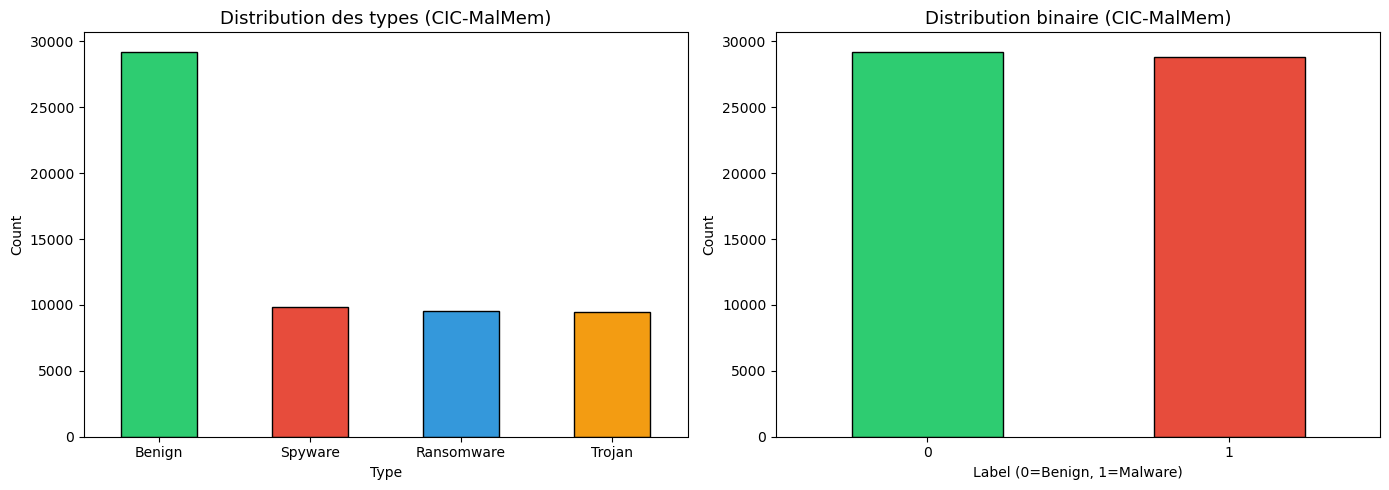

Graphique sauvegardé ✅


In [7]:
print("=== EDA CIC-MalMem 2022 ===")
print(f"\nNaN par colonne : {malmem.isnull().sum().sum()} total")
print(f"Doublons        : {malmem.duplicated().sum()}")

# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

malmem['MalwareType'].value_counts().plot(kind='bar', ax=axes[0], 
    color=['#2ecc71','#e74c3c','#3498db','#f39c12'], edgecolor='black')
axes[0].set_title('Distribution des types (CIC-MalMem)', fontsize=13)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

malmem['Label'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title('Distribution binaire (CIC-MalMem)', fontsize=13)
axes[1].set_xlabel('Label (0=Benign, 1=Malware)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(r"C:\PFA_Malware\results\eda_malmem_distribution.png", dpi=150)
plt.show()
print("Graphique sauvegardé ✅")

=== EDA EMBER 2018 ===
NaN dans X_train : 0
NaN dans X_test  : 0
Inf dans X_train : 0


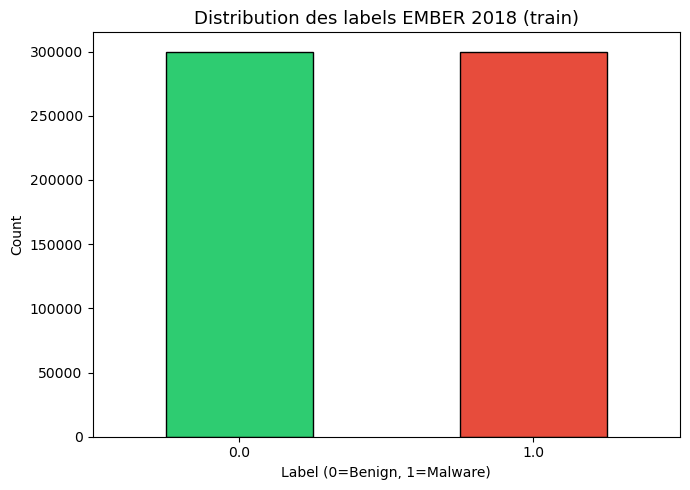

Graphique sauvegardé ✅


In [8]:
print("=== EDA EMBER 2018 ===")
print(f"NaN dans X_train : {np.isnan(X_train_ember).sum()}")
print(f"NaN dans X_test  : {np.isnan(X_test_ember).sum()}")
print(f"Inf dans X_train : {np.isinf(X_train_ember).sum()}")

# Distribution labels
fig, ax = plt.subplots(figsize=(7, 5))
pd.Series(y_train_ember).value_counts().plot(kind='bar', ax=ax,
    color=['#2ecc71','#e74c3c'], edgecolor='black')
ax.set_title('Distribution des labels EMBER 2018 (train)', fontsize=13)
ax.set_xlabel('Label (0=Benign, 1=Malware)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(r"C:\PFA_Malware\results\eda_ember_distribution.png", dpi=150)
plt.show()
print("Graphique sauvegardé ✅")

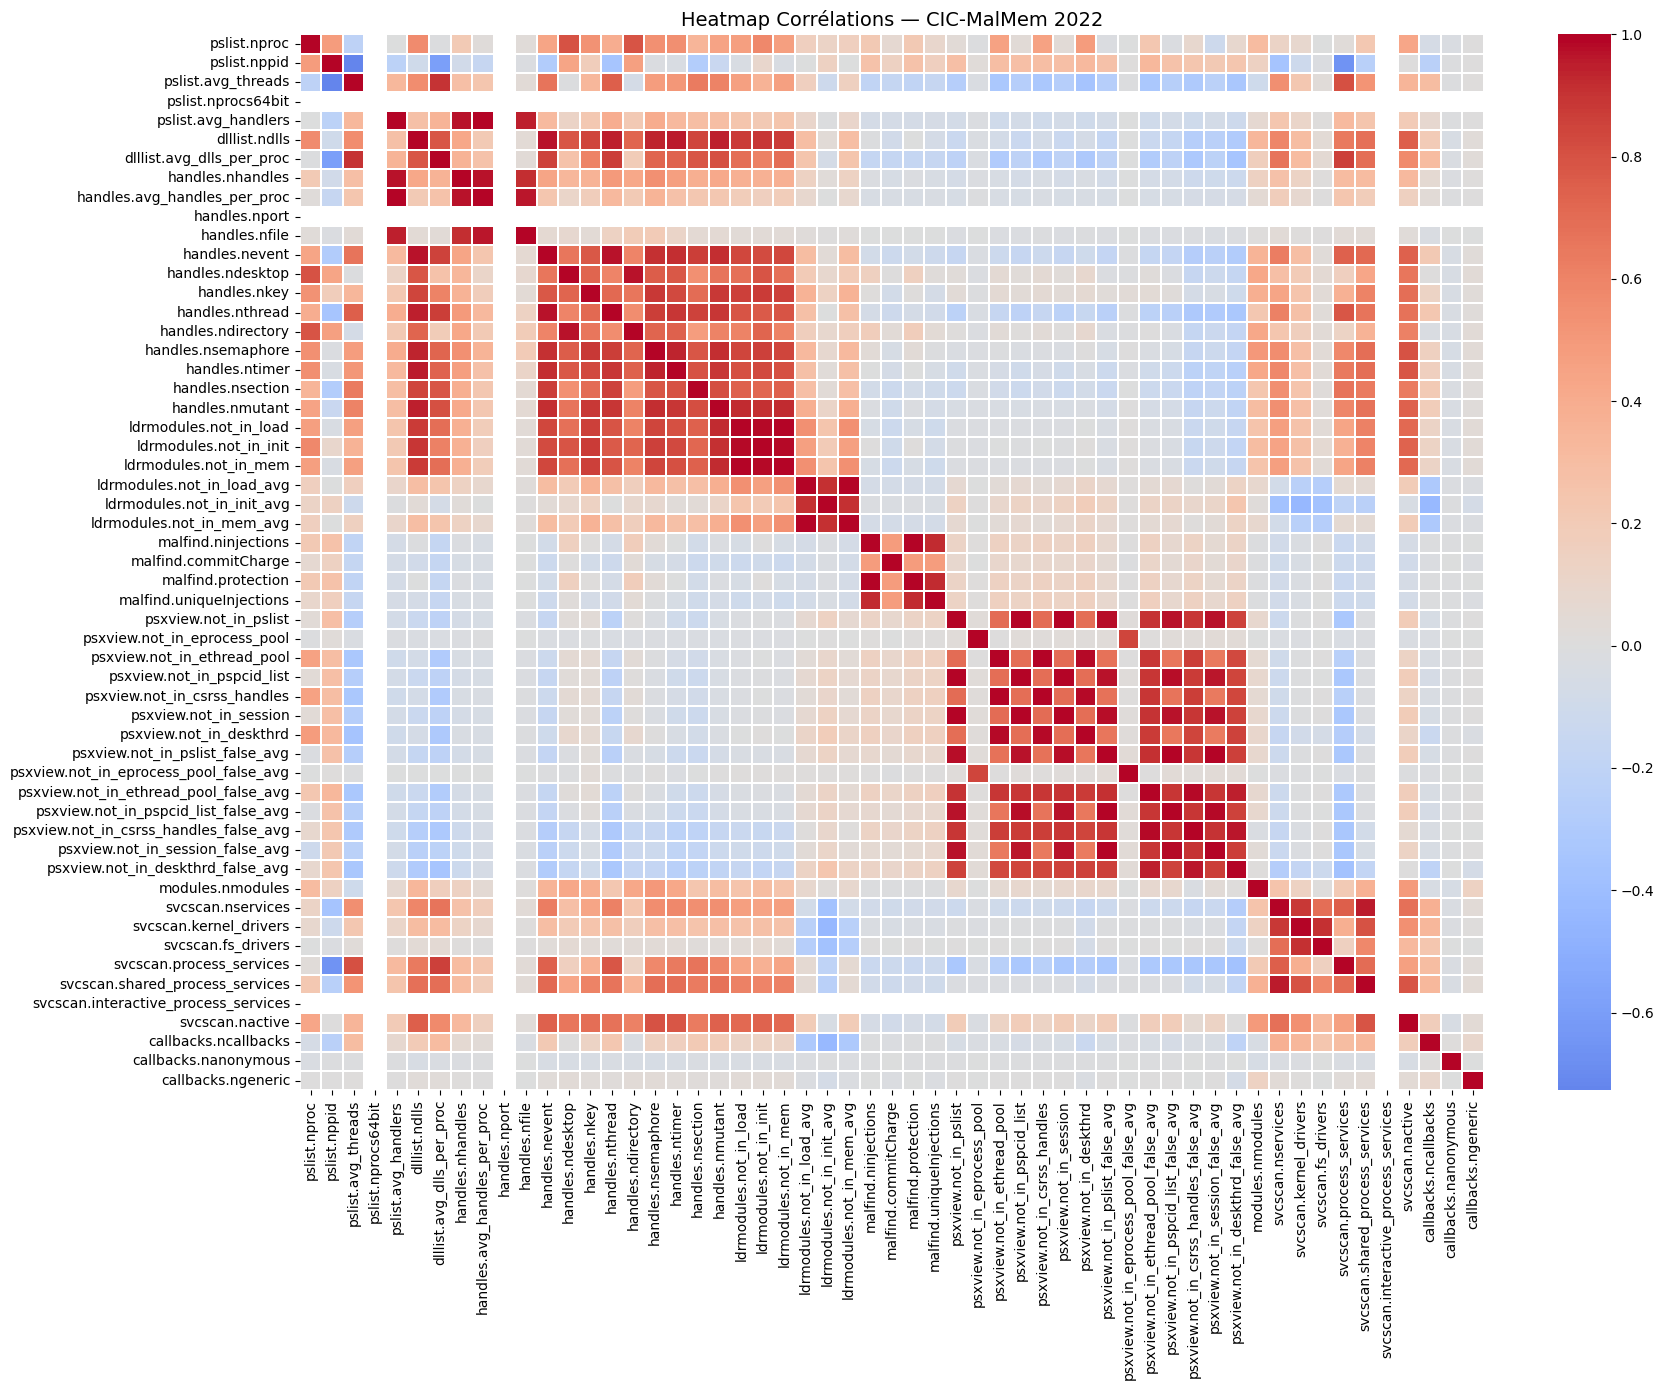

Heatmap sauvegardée ✅


In [9]:
# Sélectionner features numériques uniquement
numeric_cols = malmem.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Label']]

corr_matrix = malmem[numeric_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title('Heatmap Corrélations — CIC-MalMem 2022', fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\PFA_Malware\results\eda_malmem_correlation.png", dpi=150)
plt.show()
print("Heatmap sauvegardée ✅")

In [10]:
print("=" * 50)
print("ÉTAPE 1 & 2 — Doublons + NaN")
print("=" * 50)

# ── CIC-MalMem ───────────────────────────────────
print("\n── CIC-MalMem 2022 ──")
avant = len(malmem)
malmem = malmem.drop_duplicates()
apres = len(malmem)
print(f"Doublons supprimés : {avant - apres}")
print(f"NaN total          : {malmem.isnull().sum().sum()}")

# ── EMBER ────────────────────────────────────────
print("\n── EMBER 2018 ──")
nan_train = np.isnan(X_train_ember).sum()
inf_train = np.isinf(X_train_ember).sum()
nan_test  = np.isnan(X_test_ember).sum()
inf_test  = np.isinf(X_test_ember).sum()

print(f"NaN X_train : {nan_train} | Inf X_train : {inf_train}")
print(f"NaN X_test  : {nan_test}  | Inf X_test  : {inf_test}")

# Remplacer NaN et Inf si présents
if nan_train > 0 or inf_train > 0:
    X_train_ember = np.nan_to_num(X_train_ember, nan=0.0, posinf=0.0, neginf=0.0)
    print("  → NaN/Inf remplacés par 0 dans X_train ✅")
if nan_test > 0 or inf_test > 0:
    X_test_ember = np.nan_to_num(X_test_ember, nan=0.0, posinf=0.0, neginf=0.0)
    print("  → NaN/Inf remplacés par 0 dans X_test ✅")

print("\n✅ Étapes 1 & 2 terminées")

ÉTAPE 1 & 2 — Doublons + NaN

── CIC-MalMem 2022 ──
Doublons supprimés : 25
NaN total          : 0

── EMBER 2018 ──
NaN X_train : 0 | Inf X_train : 0
NaN X_test  : 0  | Inf X_test  : 0

✅ Étapes 1 & 2 terminées


In [11]:
print("=" * 50)
print("ÉTAPE 3 — Traitement des Outliers (CIC-MalMem)")
print("=" * 50)

numeric_cols = malmem.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Label']]

avant = len(malmem)
outlier_mask = pd.Series([False] * len(malmem), index=malmem.index)

for col in numeric_cols:
    Q1 = malmem[col].quantile(0.25)
    Q3 = malmem[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outlier_mask |= (malmem[col] < lower) | (malmem[col] > upper)

print(f"Samples avec outliers extrêmes : {outlier_mask.sum()}")
print(f"Pourcentage                    : {100*outlier_mask.sum()/len(malmem):.2f}%")

# On utilise seuil 3*IQR (conservateur) car outliers malware = comportements réels
# On winsorise plutôt que supprimer
for col in numeric_cols:
    Q1 = malmem[col].quantile(0.25)
    Q3 = malmem[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    malmem[col] = malmem[col].clip(lower=lower, upper=upper)

print(f"\nWinsorisation appliquée sur {len(numeric_cols)} features ✅")
print(f"Shape après étape 3 : {malmem.shape}")
print("\n✅ Étape 3 terminée")

ÉTAPE 3 — Traitement des Outliers (CIC-MalMem)
Samples avec outliers extrêmes : 11419
Pourcentage                    : 19.68%

Winsorisation appliquée sur 55 features ✅
Shape après étape 3 : (58033, 57)

✅ Étape 3 terminée


In [12]:
print("=" * 50)
print("ÉTAPE 4 — Encodage variables catégorielles")
print("=" * 50)

from sklearn.preprocessing import LabelEncoder

# CIC-MalMem : encoder MalwareType → entier (pour usage multiclasse futur)
le = LabelEncoder()
malmem['MalwareType_encoded'] = le.fit_transform(malmem['MalwareType'])

print("── CIC-MalMem ──")
print(f"Mapping MalwareType : { {cls: idx for idx, cls in enumerate(le.classes_)} }")
print(f"Colonnes object restantes : {malmem.select_dtypes(include='object').columns.tolist()}")

# Supprimer colonne MalwareType (texte) — on garde Label (binaire) et MalwareType_encoded
malmem = malmem.drop(columns=['MalwareType'])

print(f"Shape après encodage : {malmem.shape}")
print(f"\nTypes finaux :\n{malmem.dtypes.value_counts()}")
print("\n✅ Étape 4 terminée")

ÉTAPE 4 — Encodage variables catégorielles
── CIC-MalMem ──
Mapping MalwareType : {'Benign': 0, 'Ransomware': 1, 'Spyware': 2, 'Trojan': 3}
Colonnes object restantes : ['MalwareType']
Shape après encodage : (58033, 57)

Types finaux :
int16      23
int8       14
float32    11
float64     4
int32       3
int64       2
Name: count, dtype: int64

✅ Étape 4 terminée


In [13]:
print("=" * 50)
print("ÉTAPE 5 — Split 70/15/15 + Normalisation")
print("=" * 50)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── CIC-MalMem ───────────────────────────────────
print("\n── CIC-MalMem 2022 ──")

feature_cols = [c for c in malmem.columns if c not in ['Label', 'MalwareType_encoded']]
X_malmem = malmem[feature_cols].values
y_malmem = malmem['Label'].values

# Split 70 / 15 / 15 stratifié
X_m_train, X_m_temp, y_m_train, y_m_temp = train_test_split(
    X_malmem, y_malmem, test_size=0.30, random_state=42, stratify=y_malmem)
X_m_val, X_m_test, y_m_val, y_m_test = train_test_split(
    X_m_temp, y_m_temp, test_size=0.50, random_state=42, stratify=y_m_temp)

print(f"Train : {X_m_train.shape} | {pd.Series(y_m_train).value_counts().to_dict()}")
print(f"Val   : {X_m_val.shape}   | {pd.Series(y_m_val).value_counts().to_dict()}")
print(f"Test  : {X_m_test.shape}  | {pd.Series(y_m_test).value_counts().to_dict()}")

# StandardScaler fitté UNIQUEMENT sur train
scaler_malmem = StandardScaler()
X_m_train = scaler_malmem.fit_transform(X_m_train)
X_m_val   = scaler_malmem.transform(X_m_val)
X_m_test  = scaler_malmem.transform(X_m_test)
print("StandardScaler appliqué ✅")

# ── EMBER ────────────────────────────────────────
print("\n── EMBER 2018 ──")

# Split train → 70% train / 15% val (le test set EMBER est déjà séparé)
X_e_train, X_e_val, y_e_train, y_e_val = train_test_split(
    X_train_ember, y_train_ember, test_size=0.20, random_state=42, stratify=y_train_ember)

print(f"Train : {X_e_train.shape} | {pd.Series(y_e_train).value_counts().to_dict()}")
print(f"Val   : {X_e_val.shape}   | {pd.Series(y_e_val).value_counts().to_dict()}")
print(f"Test  : {X_test_ember.shape}  | {pd.Series(y_test_ember).value_counts().to_dict()}")

scaler_ember = StandardScaler()
X_e_train = scaler_ember.fit_transform(X_e_train)
X_e_val   = scaler_ember.transform(X_e_val)
X_e_test  = scaler_ember.transform(X_test_ember)
print("StandardScaler appliqué ✅")

print("\n✅ Étape 5 terminée")

ÉTAPE 5 — Split 70/15/15 + Normalisation

── CIC-MalMem 2022 ──
Train : (40623, 55) | {0: 20459, 1: 20164}
Val   : (8705, 55)   | {0: 4384, 1: 4321}
Test  : (8705, 55)  | {0: 4384, 1: 4321}
StandardScaler appliqué ✅

── EMBER 2018 ──
Train : (480000, 2381) | {0.0: 240000, 1.0: 240000}
Val   : (120000, 2381)   | {0.0: 60000, 1.0: 60000}
Test  : (200000, 2381)  | {1.0: 100000, 0.0: 100000}
StandardScaler appliqué ✅

✅ Étape 5 terminée


In [14]:
print("=" * 50)
print("ÉTAPE 6 — Déséquilibre de classes")
print("=" * 50)

# CIC-MalMem
ratio_malmem = pd.Series(y_m_train).value_counts()
print(f"\n── CIC-MalMem train ──")
print(f"Benign   : {ratio_malmem[0]}")
print(f"Malware  : {ratio_malmem[1]}")
print(f"Ratio    : {ratio_malmem[0]/ratio_malmem[1]:.2f}")

# EMBER
ratio_ember = pd.Series(y_e_train).value_counts()
print(f"\n── EMBER train ──")
print(f"Benign   : {ratio_ember[0.0]}")
print(f"Malware  : {ratio_ember[1.0]}")
print(f"Ratio    : {ratio_ember[0.0]/ratio_ember[1.0]:.2f}")

print("\n→ Si ratio < 3 : pas besoin de SMOTE")
print("→ Si ratio > 3 : SMOTE nécessaire")
print("\n✅ Étape 6 terminée")

ÉTAPE 6 — Déséquilibre de classes

── CIC-MalMem train ──
Benign   : 20459
Malware  : 20164
Ratio    : 1.01

── EMBER train ──
Benign   : 240000
Malware  : 240000
Ratio    : 1.00

→ Si ratio < 3 : pas besoin de SMOTE
→ Si ratio > 3 : SMOTE nécessaire

✅ Étape 6 terminée


In [15]:
print("=" * 50)
print("ÉTAPE 7 — Sélection et Réduction de Features")
print("=" * 50)

from sklearn.feature_selection import SelectKBest, f_classif

# ── CIC-MalMem ───────────────────────────────────
print("\n── CIC-MalMem 2022 ──")
print(f"Features avant sélection : {X_m_train.shape[1]}")

# Supprimer features avec corrélation > 0.95
corr_matrix = pd.DataFrame(X_m_train).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Features hautement corrélées (>0.95) : {len(to_drop)}")

X_m_train = np.delete(X_m_train, to_drop, axis=1)
X_m_val   = np.delete(X_m_val,   to_drop, axis=1)
X_m_test  = np.delete(X_m_test,  to_drop, axis=1)
print(f"Features après suppression corrélées : {X_m_train.shape[1]}")

# SelectKBest sur ce qui reste
k_malmem = min(30, X_m_train.shape[1])
selector_malmem = SelectKBest(f_classif, k=k_malmem)
X_m_train = selector_malmem.fit_transform(X_m_train, y_m_train)
X_m_val   = selector_malmem.transform(X_m_val)
X_m_test  = selector_malmem.transform(X_m_test)
print(f"Features finales retenues (SelectKBest k={k_malmem}) : {X_m_train.shape[1]}")

# ── EMBER ────────────────────────────────────────
print("\n── EMBER 2018 ──")
print(f"Features avant sélection : {X_e_train.shape[1]}")

# SelectKBest top 200 features (2381 → 200)
k_ember = 200
selector_ember = SelectKBest(f_classif, k=k_ember)
X_e_train = selector_ember.fit_transform(X_e_train, y_e_train)
X_e_val   = selector_ember.transform(X_e_val)
X_e_test  = selector_ember.transform(X_e_test)
print(f"Features finales retenues (SelectKBest k={k_ember}) : {X_e_train.shape[1]}")

print("\n✅ Étape 7 terminée")

ÉTAPE 7 — Sélection et Réduction de Features

── CIC-MalMem 2022 ──
Features avant sélection : 55
Features hautement corrélées (>0.95) : 24
Features après suppression corrélées : 31
Features finales retenues (SelectKBest k=30) : 30

── EMBER 2018 ──
Features avant sélection : 2381


C:\Users\Alahyane Yassine\anaconda3\envs\malware_env\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 3  8 26] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Alahyane Yassine\anaconda3\envs\malware_env\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\Alahyane Yassine\anaconda3\envs\malware_env\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [627 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676 893
 894 895 896 897 898 899 900 901 902 903 904 905 906 907 908 909 910 911
 912 913 914 915 916 917 918 919 920 921 922 923 924 925 926 927 928 929
 930 931 932 933 934 935 936 937 938 939 940 941 942] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Alahyane Yassine\anaco

Features finales retenues (SelectKBest k=200) : 200

✅ Étape 7 terminée


In [16]:
import numpy as np

# Vérification directe des fichiers bruts
X_train_raw = np.memmap(
    r"C:\PFA_Malware\data\raw\ember2018\X_train.dat",
    dtype=np.float32, mode="r", shape=(800000, 2381))

y_train_raw = np.memmap(
    r"C:\PFA_Malware\data\raw\ember2018\y_train.dat",
    dtype=np.float32, mode="r", shape=(800000,))

print("=== X_train.dat ===")
print(f"Min    : {X_train_raw.min():.4f}")
print(f"Max    : {X_train_raw.max():.4f}")
print(f"Mean   : {X_train_raw.mean():.4f}")
print(f"Non-zero : {np.count_nonzero(X_train_raw):,}")

print("\n=== y_train.dat ===")
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  label {int(u):2d} : {c:,} samples")

=== X_train.dat ===
Min    : -4278190080.0000
Max    : 4294967296.0000
Mean   : 575050.5000
Non-zero : 528,599,419

=== y_train.dat ===
  label -1 : 200,000 samples
  label  0 : 300,000 samples
  label  1 : 300,000 samples


In [17]:
print("=== VÉRIFICATION FINALE PHASE 1 ===")

# CIC-MalMem
var_m = np.var(X_m_train, axis=0)
print(f"\n── CIC-MalMem ──")
print(f"Shape Train/Val/Test : {X_m_train.shape} / {X_m_val.shape} / {X_m_test.shape}")
print(f"Variance min/max     : {var_m.min():.4f} / {var_m.max():.4f}")
print(f"Features variance==0 : {np.sum(var_m == 0)}")

# EMBER
var_e = np.var(X_e_train, axis=0)
print(f"\n── EMBER ──")
print(f"Shape Train/Val/Test : {X_e_train.shape} / {X_e_val.shape} / {X_e_test.shape}")
print(f"Variance min/max     : {var_e.min():.4f} / {var_e.max():.4f}")
print(f"Features variance==0 : {np.sum(var_e == 0)}")

print("\n✅ Vérification terminée")

=== VÉRIFICATION FINALE PHASE 1 ===

── CIC-MalMem ──
Shape Train/Val/Test : (40623, 30) / (8705, 30) / (8705, 30)
Variance min/max     : 0.0000 / 1.0000
Features variance==0 : 2

── EMBER ──
Shape Train/Val/Test : (480000, 200) / (120000, 200) / (200000, 200)
Variance min/max     : 1.0000 / 1.0000
Features variance==0 : 0

✅ Vérification terminée


In [18]:
from sklearn.feature_selection import VarianceThreshold

vt_final = VarianceThreshold(threshold=0.0)
X_m_train = vt_final.fit_transform(X_m_train)
X_m_val   = vt_final.transform(X_m_val)
X_m_test  = vt_final.transform(X_m_test)

var_final = np.var(X_m_train, axis=0)
print(f"CIC-MalMem features finales : {X_m_train.shape[1]}")
print(f"Variance min : {var_final.min():.6f}")
print(f"Features constantes : {np.sum(var_final == 0)}")

CIC-MalMem features finales : 28
Variance min : 1.000000
Features constantes : 0


In [19]:
import joblib, os

processed_dir = r"C:\PFA_Malware\data\processed"

np.save(os.path.join(processed_dir, "malmem_X_train.npy"), X_m_train)
np.save(os.path.join(processed_dir, "malmem_X_val.npy"),   X_m_val)
np.save(os.path.join(processed_dir, "malmem_X_test.npy"),  X_m_test)
np.save(os.path.join(processed_dir, "malmem_y_train.npy"), y_m_train)
np.save(os.path.join(processed_dir, "malmem_y_val.npy"),   y_m_val)
np.save(os.path.join(processed_dir, "malmem_y_test.npy"),  y_m_test)
joblib.dump(scaler_malmem,   os.path.join(processed_dir, "scaler_malmem.pkl"))
joblib.dump(selector_malmem, os.path.join(processed_dir, "selector_malmem.pkl"))

np.save(os.path.join(processed_dir, "ember_X_train.npy"), X_e_train)
np.save(os.path.join(processed_dir, "ember_X_val.npy"),   X_e_val)
np.save(os.path.join(processed_dir, "ember_X_test.npy"),  X_e_test)
np.save(os.path.join(processed_dir, "ember_y_train.npy"), y_e_train)
np.save(os.path.join(processed_dir, "ember_y_val.npy"),   y_e_val)
np.save(os.path.join(processed_dir, "ember_y_test.npy"),  y_test_ember)
joblib.dump(scaler_ember,   os.path.join(processed_dir, "scaler_ember.pkl"))
joblib.dump(selector_ember, os.path.join(processed_dir, "selector_ember.pkl"))

print(f"CIC-MalMem : Train {X_m_train.shape} | Val {X_m_val.shape} | Test {X_m_test.shape}")
print(f"EMBER      : Train {X_e_train.shape} | Val {X_e_val.shape} | Test {X_e_test.shape}")
print("\n🎉 PHASE 1 COMPLÈTEMENT TERMINÉE — Données sauvegardées !")

CIC-MalMem : Train (40623, 28) | Val (8705, 28) | Test (8705, 28)
EMBER      : Train (480000, 200) | Val (120000, 200) | Test (200000, 200)

🎉 PHASE 1 COMPLÈTEMENT TERMINÉE — Données sauvegardées !
